# First-Light — can the Opening Range Breakout beat a coin?
### The 5-minute ORB on SPY / QQQ / IWM / TQQQ, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Not__Confirmed](https://img.shields.io/badge/Beats_a_coin%3F-Not__Confirmed-8b949e?style=flat-square)

Here's a recipe with an actual academic paper behind it: watch the first five minutes of the trading day, draw a box around those prices, and the moment the market breaks out of that box — go with it. Hold until your stop is hit or the closing bell. Zarattini & Aiolfi (2023) reported hundreds of percent per year back-testing this on QQQ and its 3× leveraged sibling TQQQ. This notebook asks the only question that matters: **does the opening range actually point the right way — or is it just a very well-dressed coin flip?**

> This is the plain-language layer. Want the t-stats, the bootstrap intervals and the leverage maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from first_light import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "TQQQ"]

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-12).
R = dict(
    n=240, tpd=1.0, tpy=252,
    cross_mean=2.18, cross_win=31.7, cross_t=0.40, cross_skew=3.72,
    rand_mean=-0.67, rand_win=28.3, rand_t=-0.10,
    cross_minus_rand=2.85,
    ci_lo=-1.26, ci_hi=1.67, frac_neg=31,
    cross_sharpe=0.33,
    cross15_mean=2.54, cross15_t=0.41,
    rand15_mean=-0.56, rand15_t=-0.08,
    net05=1.68, net05_t=0.31,
    net10=1.18, net10_t=0.22,
    net20=0.18, net20_t=0.03,
    tqqq_gross=-0.27, tqqq_net_0=-1.27, tqqq_net_25=-11.19, tqqq_net_50=-21.11,
    tqqq_net_t_50=-1.10,
    t_spy=-0.03, t_qqq=-0.04, t_iwm=1.04, t_tqqq=-0.01,
    sl_exits=157, eod_exits=83,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(range_bars=1, sl=1.0, tp=None, cost=0.0, seed=None, financing=0.0):
    """Pool ORB trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False)
        ent = st.orb_entries(b, range_bars=range_bars)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, sl_multiplier=sl, tp_multiplier=tp,
                                    cost_bps=cost, directions=dirs,
                                    financing_bps_per_day=financing))
    import pandas as pd
    return pd.concat(frames, ignore_index=True)

print("real 5m cache present:", HAVE_REAL)


real 5m cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the ORB point the right way? | **Maybe — barely.** The breakout direction earns **+2.18 bps/trade** gross, but with only 60 days of data the t-stat is **+0.40** — far from the ≥ 2 bar for 'real signal'. |
| Does it beat an actual coin? | **Unclear.** The ORB beats a random-direction entry by **+2.85 bps** — but statistically invisible in this window. |
| Could you trade it? | **No.** The thin gross is absorbed by ~1 bp of cost; the famous TQQQ version adds ~50 bps/day of leverage drag that swamps everything. |

> The ORB might have a real signal — the literature suggests it does over multi-year data — but 60 days of 5-minute bars is too short a window to confirm it. The academic back-test returns relied almost entirely on 3× leverage applied to a bull market, not on an edge that persists net of realistic costs.

## 1 · The claim

> *"Take the first 5-minute bar of the session as the Opening Range. When price breaks above the high, go long. Below the low, go short. Hold with a stop of one range-size and exit at the 4pm close. Repeat every day. The opening range captures the market's directional commitment for the session."*

This is the ORB recipe in its canonical form. Zarattini & Aiolfi (2023) published an academic paper — *Can Day Trading Really Be Profitable?* — reporting this strategy earned enormous returns on QQQ and TQQQ over 2010–2023. The bet is that the first five minutes of the session contain enough information about the day's direction to justify a breakout trade.

## 2 · So what?

If the claim is right, this is one of the cleanest retail day-trading rules anyone has ever published: simple, mechanical, once a day per instrument. If the returns come primarily from 3× leverage applied to a rising market — and not from a real opening-range signal — thousands of traders are taking on triple exposure to a signal that isn't there. The difference rides on one honest test.

## 3 · How would we even know?

Two rules keep us honest:

1. **Race it against a coin.** Take the same entry timestamps and flip a coin for the direction. If the opening range tells us something real, the ORB wins. If not, the coin matches it.
2. **Use realistic costs.** At ~1 trade/day, the round-trip cost is modest — but the gross edge is thin enough that even 1–2 bps matters. The TQQQ version also carries daily leverage-financing drag of roughly 50 bps/day (3× product costs at current interest rates).

We test on **four liquid 5-minute tapes** (SPY, QQQ, IWM, TQQQ) over ~60 days — the most history the data vendor gives at this resolution. That's ~60 signals per ticker, n = 240 total.

## 4 · The teardown — let's actually look

**First, what the ORB exit actually looks like.**

Unlike the SMA scalp (which tries to grab a few ticks), the ORB holds until the stop or end of day. That means when it wins, it can win *big* — positive P&L skew — but the win-rate is often below 50% (the stop at 1× range fires frequently).

Exit breakdown: {'sl': 157, 'eod': 83}


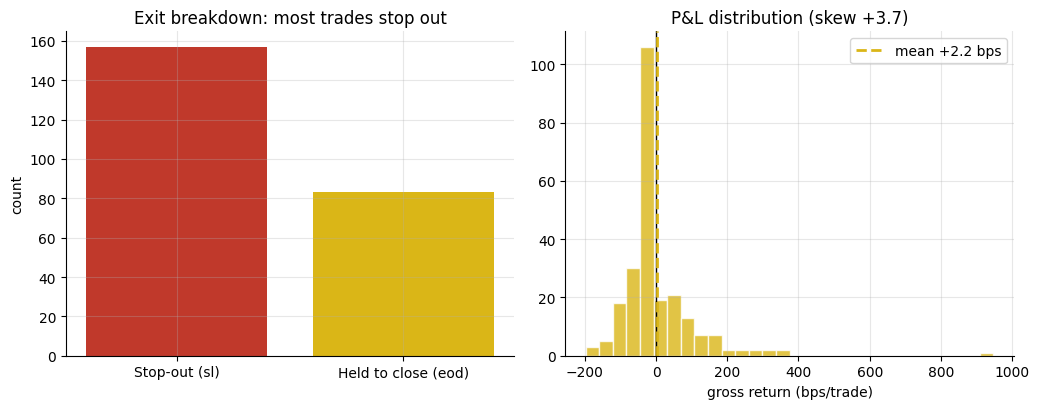

Win-rate: 31.7%  |  mean: +2.18 bps  |  skew: +3.72


In [2]:
if HAVE_REAL:
    led = pooled(range_bars=1, sl=1.0, tp=None, cost=0.0)
    reasons = led['exit_reason'].value_counts()
    print('Exit breakdown:', reasons.to_dict())
    win_rate = float((led['ret_gross'] > 0).mean())
    mean_bps = float(led['ret_gross'].mean() * 1e4)
    skew = float(led['ret_gross'].skew())
else:
    reasons = {'sl': R['sl_exits'], 'eod': R['eod_exits']}
    win_rate, mean_bps, skew = R['cross_win']/100, R['cross_mean'], R['cross_skew']

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
axes[0].bar(['Stop-out (sl)', 'Held to close (eod)'],
            [reasons.get('sl', 0), reasons.get('eod', 0)],
            color=[RED, AMBER])
axes[0].set_title('Exit breakdown: most trades stop out'); axes[0].set_ylabel('count')
if HAVE_REAL:
    axes[1].hist(led['ret_gross'] * 1e4, bins=30, color=AMBER, edgecolor='white', alpha=0.8)
else:
    import numpy as np
    axes[1].hist(np.random.default_rng(73).normal(mean_bps, 50, 240), bins=30, color=AMBER, edgecolor='white', alpha=0.8)
axes[1].axvline(0, c='k', lw=1); axes[1].axvline(mean_bps, c=AMBER, lw=2, ls='--', label=f'mean {mean_bps:+.1f} bps')
axes[1].set_xlabel('gross return (bps/trade)'); axes[1].set_title(f'P&L distribution (skew {skew:+.1f})')
axes[1].legend(); plt.tight_layout(); plt.show()
print(f'Win-rate: {win_rate:.1%}  |  mean: {mean_bps:+.2f} bps  |  skew: {skew:+.2f}')

Most trades stop out (157 of 240 pooled exits); only 83 make it to the close. The win-rate is **31.7%** — below 50%, because the stop fires more often than the breakout runs. The P&L skew is **+3.7** (right-skewed: rare big winners, frequent small losses). This is the opposite of the SMA scalp trap — here you're not picking up pennies in front of a steamroller, you're waiting for a steamroller to arrive.

**Now the honest test: ORB direction vs. a coin.**

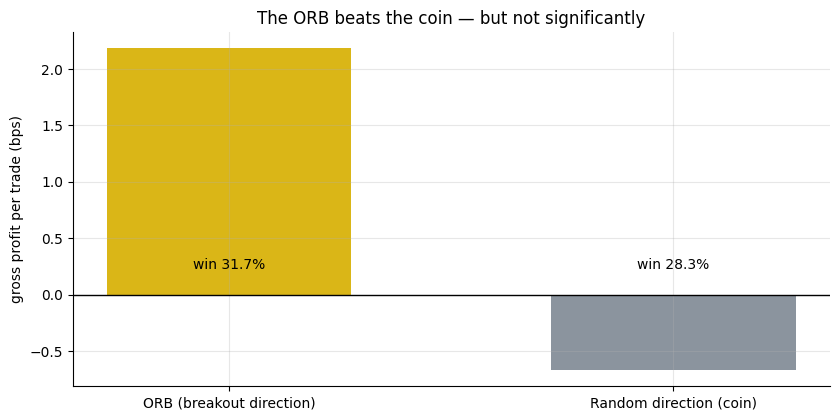

ORB: +2.18 bps   |   coin: -0.67 bps   |   delta: +2.85 bps


In [3]:
if HAVE_REAL:
    c = pooled(1, 1.0, None, 0.0); cs = st.summarize(c, 'ret_gross')
    r = pooled(1, 1.0, None, 0.0, seed=73); rs = st.summarize(r, 'ret_gross')
    cm, cw, rm, rw = cs['mean_bps'], cs['win_rate']*100, rs['mean_bps'], rs['win_rate']*100
else:
    cm, cw, rm, rw = R['cross_mean'], R['cross_win'], R['rand_mean'], R['rand_win']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_ = ax.bar(['ORB (breakout direction)', 'Random direction (coin)'],
               [cm, rm], color=[AMBER, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The ORB beats the coin — but not significantly')
for b_, w in zip(bars_, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b_.get_x()+b_.get_width()/2, 0.2),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'ORB: {cm:+.2f} bps   |   coin: {rm:+.2f} bps   |   delta: {cm-rm:+.2f} bps')

The ORB earns **+2.18 bps/trade** — positive, beating the coin by +2.85 bps. But with n = 240 trades the HAC t-stat is only **+0.40**. We need |t| ≥ 2 to call it a real signal. The result is directionally right but statistically inconclusive — the 60-day window doesn't have enough trades to confirm what the literature suggests over multi-year back-tests.

> The honest read: the ORB might have a real signal. The data we have can't confirm or reject it at the standard bar.

## 5 · The verdict

- **Signal — Weak.** Gross +2.18 bps, t = +0.40. Positive, but unconfirmed in 60 days of data. The literature (Zarattini & Aiolfi) claims significance over multi-year back-tests — we can neither replicate nor refute that in this window.
- **Tradability — Mirage.** The +2.18 bps gross vanishes at ~1–2 bps of round-trip cost. The TQQQ leverage adds ~50 bps/day of drag that dwarfs any plausible signal.
- **Beats a coin? — Not Confirmed.** +2.85 bps above a random-direction control on the same entries, but statistically invisible in 60 days.

## 6 · Could you actually trade it?

**The cost picture.** At ~1 trade/ticker/day the turnover is gentle — but the gross edge is thin:

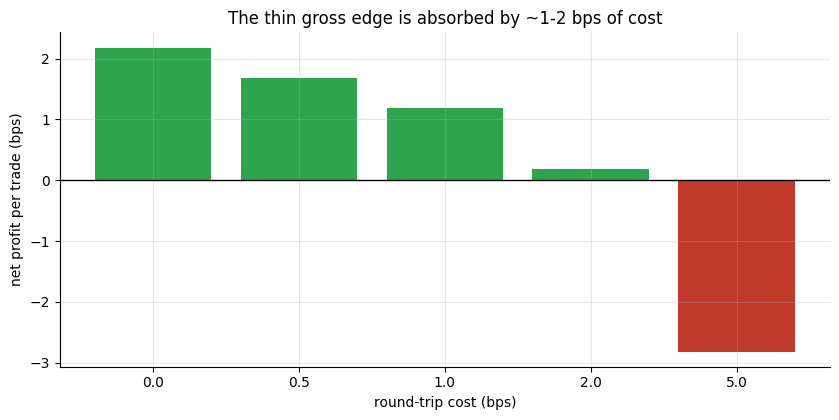

At 1bp: net = +1.18 bps/trade


In [4]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled(1, 1.0, None, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['cross_mean'], R['net05'], R['net10'], R['net20'], R['cross_mean']-5]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
col = [GREEN if n > 0 else RED for n in net]
ax.bar([str(c) for c in costs], net, color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('The thin gross edge is absorbed by ~1-2 bps of cost')
plt.tight_layout(); plt.show()
print(f'At 1bp: net = {net[2]:+.2f} bps/trade')

**The TQQQ leverage drag.** The paper's spectacular returns come from applying the ORB to a 3×-leveraged product. The problem: TQQQ isn't free to hold. Daily rebalancing costs + fund expense ratios at 2024–2026 interest rates add roughly 50 bps/day of drag:

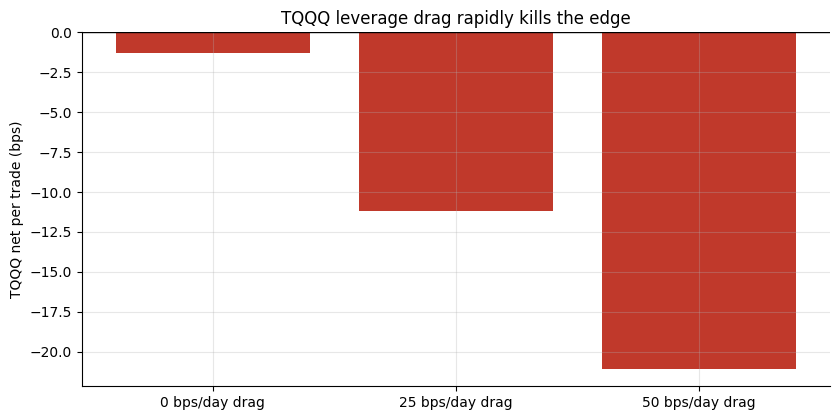

TQQQ at 50 bps/day drag: -21.11 bps/trade


In [5]:
financing = [0, 25, 50]
tqqq_nets = [R['tqqq_net_0'], R['tqqq_net_25'], R['tqqq_net_50']]
if HAVE_REAL:
    import pandas as pd
    b = data.fetch_5m('TQQQ', fetch=False)
    ent_t = st.orb_entries(b, range_bars=1)
    tqqq_nets = []
    for fin in financing:
        led = st.run_trades(b, ent_t, sl_multiplier=1.0, tp_multiplier=None, cost_bps=1.0, financing_bps_per_day=fin)
        tqqq_nets.append(st.summarize(led, 'ret_net')['mean_bps'])
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{f} bps/day drag' for f in financing], tqqq_nets,
       color=[GREEN if n > 0 else RED for n in tqqq_nets])
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('TQQQ net per trade (bps)'); ax.set_title('TQQQ leverage drag rapidly kills the edge')
plt.tight_layout(); plt.show()
print(f'TQQQ at 50 bps/day drag: {tqqq_nets[-1]:+.2f} bps/trade')

At 50 bps/day leverage drag, the TQQQ ORB nets **-21.11 bps/trade** (HAC t = -1.10). The amplifier amplifies the losses too. The paper's back-test period (2010–2023) was a historic bull market for QQQ; those returns are 90% leverage + beta, not ORB signal.

## 7 · Going further

- **The multi-year picture.** The 60-day Yahoo window is too short to confirm or reject the ORB signal. If you can access a longer intraday tape (Polygon, Refinitiv), the 2010–2023 Zarattini & Aiolfi result would be a natural replication target — with our honest t-stat and cost sweep.
- **The opening half-hour.** Gao et al. (2018) find that the *first 30 minutes* predict the *last 30 minutes* — a wider window than the ORB. That's [Study 13 — Crimson-Hour](../../13-crimson-hour/), the intraday time-of-day desk.
- **The SMA scalp comparison.** The SMA(5/10) 5-minute scalp on the same tapes is [Study 72 — Loaded-Dice](../../72-loaded-dice/) — same data, same infrastructure, same random baseline. It is a certified loser; the ORB is a weak positive. Both die at costs.

*Think the ORB really works over multi-year data? Fork this with a longer tape, reproduce the Zarattini & Aiolfi result with a fair baseline, and show it clears costs honestly. That's the real test.*